In [14]:
import preprocessing
%load_ext autoreload

In [317]:
autoreload

##データ加工

In [3]:
results_preprocessed=preprocessing.process_results()

In [4]:
results_preprocessed.info()

<class 'pandas.core.frame.DataFrame'>
Index: 140686 entries, 41778 to 39941
Data columns (total 15 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   race_id      140686 non-null  int64  
 1   horse_id     140686 non-null  int64  
 2   jockey_id    140686 non-null  int64  
 3   trainer_id   140686 non-null  int64  
 4   rank         140686 non-null  int64  
 5   wakuban      140686 non-null  int64  
 6   umaban       140686 non-null  int64  
 7   sex          140686 non-null  int64  
 8   age          140686 non-null  int64  
 9   weight       140686 non-null  int64  
 10  weight_diff  140686 non-null  int64  
 11  tansyo_odds  140686 non-null  float64
 12  popularity   140686 non-null  int64  
 13  impost       140686 non-null  float64
 14  agari        140685 non-null  float64
dtypes: float64(3), int64(12)
memory usage: 17.2 MB


In [5]:
#重複チェック
results_preprocessed.duplicated(subset=["race_id","horse_id"]).sum()

0

In [6]:
#欠損チェック
results_preprocessed.isnull().sum()

race_id        0
horse_id       0
jockey_id      0
trainer_id     0
rank           0
wakuban        0
umaban         0
sex            0
age            0
weight         0
weight_diff    0
tansyo_odds    0
popularity     0
impost         0
agari          1
dtype: int64

In [7]:
horse_results_preprocessed=preprocessing.process_horse_results()

/home/jawa/horse_ai/horse_race_prediction/v2_0_0/src/preprocessing.py:124: DtypeWarning: Columns (3,12,16,17,20,27,29) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(input_dir/save_filename, sep="\t")


In [8]:
horse_results_preprocessed

,horse_id,date,rank,prize,rank_diff,weather,race_type,course_len,ground_state,agari,race_class,n_horses
0,2011106610,2014-01-19,6,0.0,0.7,0.0,1,1600,0.0,37.4,0.0,16.0
1,2011106610,2014-03-01,1,500.0,0.0,1.0,1,1800,0.0,35.8,1.0,16.0
2,2011106610,2014-03-23,12,0.0,2.6,0.0,1,1800,0.0,38.6,NaN,15.0
3,2011106610,2014-04-19,8,0.0,0.6,0.0,1,1600,0.0,35.4,2.0,13.0
4,2011106610,2014-05-25,10,0.0,0.6,0.0,1,1600,0.0,35.1,2.0,16.0
...,...,...,...,...,...,...,...,...,...,...,...,...
341149,2022190001,2024-08-04,1,0.0,NaN,NaN,1,1700,2.0,NaN,1.0,10.0
341150,2022190001,2024-09-08,1,0.0,NaN,NaN,1,1600,0.0,NaN,5.0,12.0
341151,2022190001,2024-10-04,1,0.0,NaN,NaN,1,1700,0.0,NaN,NaN,11.0
341152,2022190001,2024-11-02,2,0.0,NaN,NaN,1,1600,0.0,NaN,NaN,14.0


In [9]:
horse_results_preprocessed.info()

<class 'pandas.core.frame.DataFrame'>
Index: 228254 entries, 0 to 341153
Data columns (total 12 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   horse_id      228254 non-null  int64         
 1   date          228254 non-null  datetime64[ns]
 2   rank          228254 non-null  int64         
 3   prize         228254 non-null  float64       
 4   rank_diff     227910 non-null  float64       
 5   weather       227953 non-null  float64       
 6   race_type     228254 non-null  int64         
 7   course_len    228254 non-null  int64         
 8   ground_state  228250 non-null  float64       
 9   agari         227902 non-null  float64       
 10  race_class    198932 non-null  float64       
 11  n_horses      228254 non-null  float64       
dtypes: datetime64[ns](1), float64(7), int64(4)
memory usage: 22.6 MB


In [10]:
race_info_preprocessed=preprocessing.process_race_info()

In [11]:
race_info_preprocessed

,race_id,date,race_type,around,course_len,weather,ground_state,race_class,place
0,202406010111,2024-01-06,1.0,0.0,2000,0,0,5,2
1,202503020112,2025-06-28,0.0,0.0,1700,0,0,2,9
2,202509050506,2025-12-20,0.0,0.0,1800,0,0,0,1
3,202309020109,2023-03-25,1.0,0.0,1800,1,0,2,1
4,202303020408,2023-07-09,1.0,0.0,1800,1,0,2,9
...,...,...,...,...,...,...,...,...,...
10360,202501010302,2025-08-02,0.0,0.0,1000,0,0,1,5
10361,202403020406,2024-07-07,1.0,0.0,1200,0,0,0,9
10362,202505040205,2025-10-05,1.0,1.0,2000,0,0,0,0
10363,202408060403,2024-11-10,1.0,0.0,1600,0,0,1,3


##  特徴量作成

In [12]:
from feature_engineering import FeatureCreator

In [13]:
fc=FeatureCreator()

In [14]:
fc.results

,race_id,horse_id,jockey_id,trainer_id,rank,wakuban,umaban,sex,age,weight,weight_diff,tansyo_odds,popularity,impost,agari
0,202301010101,2021100648,1095,1128,5,1,1,1,2,434,0,23.9,5,55.0,34.5
1,202301010101,2021100159,1157,1186,6,2,2,0,2,454,6,61.8,7,55.0,35.1
2,202301010101,2021100265,1197,1192,7,3,3,1,2,404,2,18.8,4,53.0,35.3
3,202301010101,2021105553,5339,1160,4,4,4,1,2,450,2,16.6,3,55.0,34.9
4,202301010101,2021101429,1170,1026,1,5,5,0,2,452,4,1.2,1,55.0,34.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
140681,202510020812,2022105755,1187,1135,5,7,14,1,3,452,4,7.2,3,53.0,34.5
140682,202510020812,2017101767,1125,1120,12,7,15,0,8,480,8,111.0,16,58.0,34.9
140683,202510020812,2020106727,1213,1205,8,8,16,0,5,544,0,18.1,5,58.0,35.3
140684,202510020812,2021103312,1154,1157,3,8,17,0,4,496,8,29.0,8,58.0,34.7


In [15]:
fc.horse_results

,horse_id,date,rank,prize,rank_diff,weather,race_type,course_len,ground_state,agari,race_class,n_horses
0,2011106610,2014-01-19,6,0.0,0.7,0.0,1,1600,0.0,37.4,0.0,16.0
1,2011106610,2014-03-01,1,500.0,0.0,1.0,1,1800,0.0,35.8,1.0,16.0
2,2011106610,2014-03-23,12,0.0,2.6,0.0,1,1800,0.0,38.6,NaN,15.0
3,2011106610,2014-04-19,8,0.0,0.6,0.0,1,1600,0.0,35.4,2.0,13.0
4,2011106610,2014-05-25,10,0.0,0.6,0.0,1,1600,0.0,35.1,2.0,16.0
...,...,...,...,...,...,...,...,...,...,...,...,...
228249,2022190001,2024-08-04,1,0.0,NaN,NaN,1,1700,2.0,NaN,1.0,10.0
228250,2022190001,2024-09-08,1,0.0,NaN,NaN,1,1600,0.0,NaN,5.0,12.0
228251,2022190001,2024-10-04,1,0.0,NaN,NaN,1,1700,0.0,NaN,NaN,11.0
228252,2022190001,2024-11-02,2,0.0,NaN,NaN,1,1600,0.0,NaN,NaN,14.0


In [16]:
features=fc.create_features()

In [17]:
features

,race_id,horse_id,date,jockey_id,trainer_id,rank,wakuban,umaban,sex,age,...,race_class,place,rank_3races,prize_3races,rank_5races,prize_5races,rank_10races,prize_10races,rank_1000races,prize_1000races
0,202301010101,2021100648,2023-07-22,1095,1128,5,1,1,1,2,...,1,5,4.500000,77.500000,4.500000,77.500000,4.500000,77.500000,4.500000,77.500000
1,202301010101,2021100159,2023-07-22,1157,1186,6,2,2,0,2,...,1,5,8.000000,0.000000,8.000000,0.000000,8.000000,0.000000,8.000000,0.000000
2,202301010101,2021100265,2023-07-22,1197,1192,7,3,3,1,2,...,1,5,5.000000,72.000000,5.000000,72.000000,5.000000,72.000000,5.000000,72.000000
3,202301010101,2021105553,2023-07-22,5339,1160,4,4,4,1,2,...,1,5,4.000000,110.000000,4.000000,110.000000,4.000000,110.000000,4.000000,110.000000
4,202301010101,2021101429,2023-07-22,1170,1026,1,5,5,0,2,...,1,5,2.000000,290.000000,2.000000,290.000000,2.000000,290.000000,2.000000,290.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
140681,202510020812,2022105755,2025-07-20,1187,1135,5,7,14,1,3,...,3,8,4.000000,754.433333,4.000000,596.660000,4.000000,596.660000,4.000000,596.660000
140682,202510020812,2017101767,2025-07-20,1125,1120,12,7,15,0,8,...,3,8,10.333333,0.000000,9.400000,22.800000,7.000000,106.210000,5.684211,102.284211
140683,202510020812,2020106727,2025-07-20,1213,1205,8,8,16,0,5,...,3,8,6.000000,132.066667,7.200000,79.240000,5.500000,206.620000,5.636364,187.836364
140684,202510020812,2021103312,2025-07-20,1154,1157,3,8,17,0,4,...,3,8,4.333333,173.333333,3.400000,252.880000,3.125000,269.925000,3.125000,269.925000


##  学習

In [49]:
from train import Trainer, create_yaml

In [50]:
create_yaml(delete_col=["race_id", "date", "rank", "target","popularity"])
r=Trainer()
evaluation_df=r.run(test_start_date="2025-05-01")

YAML ファイルを作成しました: config.yaml
(109295, 32) (31391, 32)


/home/jawa/horse_ai/horse_race_prediction/v2_0_0/src/train.py:89: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df[c] = s_tr.astype("category").cat.set_categories(category_map[c])
/home/jawa/horse_ai/horse_race_prediction/v2_0_0/src/train.py:90: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df[c] = test_df[c].astype("string").astype("category").cat.set_categories(category_map[c])
/home/jawa/horse_ai/horse_race_prediction/v2_0_0/src/train.py:89: SettingWithCopyWarning: 
A value is trying to be set

[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Number of positive: 7984, number of negative: 101311
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.064111 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 16549
[LightGBM] [Info] Number of data points in the train set: 109295, number of used features: 27
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.073050 -> initscore=-2.540755
[LightGBM] [Info] Start training from score -2.540755
Training until validation scores don't improve for 100 rounds
[100]	valid's binary_logloss: 0.207098
Early stopping, best iteration is:
[39]	valid's binary_logloss: 0.202888
--------------------result---------

In [61]:
from feature_engineering  import  PredictionFeatureCreator
pfc=PredictionFeatureCreator()

##  レース予想

In [62]:
import preprocessing

horse_results_preprocessed=preprocessing.process_horse_results(
    save_filename="horse_results_prediction.csv"
)

In [63]:
horse_results_preprocessed.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5385 entries, 73 to 14032
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   horse_id      5385 non-null   int64         
 1   date          5385 non-null   datetime64[ns]
 2   rank          5385 non-null   int64         
 3   prize         5385 non-null   float64       
 4   rank_diff     5380 non-null   float64       
 5   weather       5380 non-null   float64       
 6   race_type     5385 non-null   int64         
 7   course_len    5385 non-null   int64         
 8   ground_state  5384 non-null   float64       
 9   agari         5380 non-null   float64       
 10  race_class    4783 non-null   float64       
 11  n_horses      5384 non-null   float64       
dtypes: datetime64[ns](1), float64(7), int64(4)
memory usage: 546.9 KB


## レース当日

In [64]:
autoreload

In [65]:
pfc=PredictionFeatureCreator()
pfc.agg_horse_n_races()

In [66]:
pfc.agg_horse_n_races_df

,date,race_id,horse_id,rank_3races,prize_3races,rank_5races,prize_5races,rank_10races,prize_10races,rank_1000races,prize_1000races
0,2026-01-18,202606010704,2022106543,9.666667,28.000000,10.4,16.80,10.142857,12.000000,10.142857,12.000000
1,2026-01-18,202606010704,2019101612,5.000000,226.666667,8.8,136.00,7.900000,316.360000,7.263158,212.821053
2,2026-01-18,202606010704,2018105199,7.333333,113.333333,6.0,228.00,6.500000,142.000000,7.347826,127.217391
3,2026-01-18,202606010706,2022105258,1.666667,400.000000,2.4,284.80,3.300000,200.400000,3.300000,200.400000
4,2026-01-18,202606010708,2022105844,6.333333,266.666667,5.0,240.00,6.900000,120.000000,6.538462,134.615385
5,2026-01-18,202606010709,2018104757,9.333333,0.000000,8.8,0.00,9.800000,18.400000,7.361111,119.052778
6,2026-01-18,202606010709,2021100363,5.666667,154.666667,6.0,242.64,7.400000,279.610000,6.571429,409.400000
7,2026-01-18,202606010709,2019107075,9.333333,0.000000,10.0,0.00,8.900000,28.000000,6.859375,113.178125
8,2026-01-18,202606010709,2020103521,3.666667,357.100000,5.4,214.26,4.600000,313.150000,3.708333,470.895833
9,2026-01-18,202606010710,2022110140,10.666667,296.600000,7.4,596.72,5.000000,611.211111,5.000000,611.211111


In [67]:
features=pfc.create_features(
    race_id="202608010712",
    predict=True,
    skip_agg_horse=True
)

[INFO] tansyo_odds via API: 11 / 11
[INFO] popularity  via API: 11 / 11


In [68]:
features["tansyo_odds"].head()


0      1.2
1     25.1
2     13.2
3    140.2
4     -3.0
Name: tansyo_odds, dtype: float64

In [69]:
import prediction
prediction.predict(features)


,race_id,umaban,tansyo_odds,popularity,agari,pred
0,202608010712,1,1.2,1,NaN,0.617996
4,202608010712,5,-3.0,9999,NaN,0.617996
5,202608010712,6,-3.0,9999,NaN,0.617996
6,202608010712,7,-3.0,9999,NaN,0.617996
10,202608010712,11,4.9,2,NaN,0.303654
8,202608010712,9,10.1,3,NaN,0.119418
1,202608010712,2,25.1,5,NaN,0.063878
9,202608010712,10,28.9,6,NaN,0.061753
2,202608010712,3,13.2,4,NaN,0.036132
7,202608010712,8,50.2,7,NaN,0.029183


In [70]:
from pathlib import Path
import pandas as pd
import datetime as dt
from tqdm.notebook import tqdm
import time

# 既存 predict 関数を使う（あなたが貼った prediction.py のやつ）
from prediction import predict

# (A)で作った安全版 PredictionFeatureCreator を使う
# 同ファイルに書いたなら import 不要
from feature_engineering import PredictionFeatureCreator, RAW_DATA_DIR, DATA_DIR

POPULATION_CSV = RAW_DATA_DIR / "prediction_population" / "population.csv"

OUT_DIR = DATA_DIR / "predictions_html"
OUT_DIR.mkdir(exist_ok=True, parents=True)


def build_html_report(target_date: str, topk_per_race: int = 18) -> Path:
    pop = pd.read_csv(POPULATION_CSV, sep="\t")
    pop["date"] = pop["date"].astype(str).str.strip()

    race_ids = sorted(pop.loc[pop["date"] == target_date, "race_id"].astype(str).unique())
    if len(race_ids) == 0:
        raise ValueError(f"{target_date} の race_id が population.csv にありません")

    pfc = PredictionFeatureCreator()
    pfc.agg_horse_n_races()  # 重いので最初に1回

    now = dt.datetime.now().strftime("%Y-%m-%d %H:%M")
    parts = []
    parts.append(f"""<!doctype html>
<html lang="ja">
<head>
<meta charset="utf-8">
<meta name="viewport" content="width=device-width, initial-scale=1">
<title>予想表 {target_date}</title>
<style>
  body {{ font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Roboto, "Noto Sans JP", "Hiragino Sans", "Yu Gothic", sans-serif;
         margin: 24px; background: #fafafa; color: #111; }}
  h1 {{ margin: 0 0 8px 0; font-size: 24px; }}
  .meta {{ color: #444; margin-bottom: 18px; }}
  .toc {{ background: #fff; border-radius: 12px; padding: 14px 16px; box-shadow: 0 2px 10px rgba(0,0,0,0.06); margin-bottom: 18px; }}
  .toc a {{ text-decoration: none; margin-right: 10px; white-space: nowrap; display: inline-block; padding: 6px 10px; border-radius: 999px; background: #f1f3f5; color: #111; }}
  .race {{ background: #fff; border-radius: 14px; padding: 14px 16px; box-shadow: 0 2px 12px rgba(0,0,0,0.07); margin: 14px 0; }}
  .race h2 {{ margin: 0 0 10px 0; font-size: 18px; }}
  table {{ border-collapse: collapse; width: 100%; }}
  th, td {{ border-bottom: 1px solid #eee; padding: 8px 8px; text-align: left; font-size: 14px; }}
  th {{ background: #fbfbfb; position: sticky; top: 0; z-index: 1; }}
  .note {{ color:#555; font-size: 13px; margin-top: 8px; }}
</style>
</head>
<body>
<h1>予想表（{target_date}）</h1>
<div class="meta">生成: {now} | 上位 {topk_per_race} 頭 / レース</div>
""")

    # 目次
    parts.append('<div class="toc"><div style="margin-bottom:8px; font-weight:600;">レース一覧</div>')
    for rid in race_ids:
        parts.append(f'<a href="#r{rid}">{rid}</a>')
    parts.append("</div>")

    errors = []

    for rid in tqdm(race_ids, desc=f"Build HTML {target_date}"):
        try:
            feats = pfc.create_features(race_id=rid, predict=True, skip_agg_horse=True)
            pred_df = predict(feats)  # pred列を返す

            df = pred_df.copy()
            if "tansyo_odds" in df.columns:
                df["EV(単勝)"] = df["pred"] * df["tansyo_odds"]

            # 表示整形
            cols = ["umaban", "tansyo_odds", "popularity", "agari", "pred", "EV(単勝)"]
            cols = [c for c in cols if c in df.columns]
            df = df[cols].sort_values("pred", ascending=False).head(topk_per_race).reset_index(drop=True)
            df = df.rename(columns={
                "umaban": "馬番", "tansyo_odds": "単勝", "popularity": "人気",
                "agari": "上り", "pred": "勝率(予測)"
            })

            if "勝率(予測)" in df.columns:
                df["勝率(予測)"] = df["勝率(予測)"].map(lambda x: f"{float(x):.3f}" if pd.notna(x) else "")
            if "単勝" in df.columns:
                df["単勝"] = df["単勝"].map(lambda x: f"{float(x):.1f}" if pd.notna(x) else "")
            if "EV(単勝)" in df.columns:
                df["EV(単勝)"] = df["EV(単勝)"].map(lambda x: f"{float(x):.2f}" if pd.notna(x) else "")

            parts.append(f'<div class="race" id="r{rid}"><h2>Race {rid}</h2>')
            parts.append(df.to_html(index=False, escape=False))
            parts.append('<div class="note">EV(単勝)=勝率(予測)×単勝オッズ（単勝がある場合）</div></div>')

        except Exception as e:
            errors.append((rid, repr(e)))

        # レース間にも礼儀スリープ（内部でもsleepしてるが二重で優しく）
        time.sleep(1.0)

    if errors:
        parts.append('<div class="race"><h2>予測できなかったレース</h2>')
        parts.append(pd.DataFrame(errors, columns=["race_id", "error"]).to_html(index=False, escape=False))
        parts.append("</div>")

    parts.append("</body></html>")

    out_path = OUT_DIR / f"predictions_{target_date}.html"
    out_path.write_text("\n".join(parts), encoding="utf-8")
    return out_path


# =========================
# 実行
# =========================
target_date = "2026-01-18"
out = build_html_report(target_date, topk_per_race=18)
print("Saved:", out.resolve())


Build HTML 2026-01-18:   0%|          | 0/24 [00:00<?, ?it/s]

[INFO] tansyo_odds via API: 16 / 16
[INFO] popularity  via API: 16 / 16
[INFO] tansyo_odds via API: 16 / 16
[INFO] popularity  via API: 16 / 16
[INFO] tansyo_odds via API: 13 / 13
[INFO] popularity  via API: 13 / 13
[INFO] tansyo_odds via API: 14 / 14
[INFO] popularity  via API: 14 / 14
[INFO] tansyo_odds via API: 16 / 16
[INFO] popularity  via API: 16 / 16
[INFO] tansyo_odds via API: 14 / 14
[INFO] popularity  via API: 14 / 14
[INFO] tansyo_odds via API: 16 / 16
[INFO] popularity  via API: 16 / 16
[INFO] tansyo_odds via API: 16 / 16
[INFO] popularity  via API: 16 / 16
[INFO] tansyo_odds via API: 15 / 15
[INFO] popularity  via API: 15 / 15
[INFO] tansyo_odds via API: 16 / 16
[INFO] popularity  via API: 16 / 16
[INFO] tansyo_odds via API: 15 / 15
[INFO] popularity  via API: 15 / 15
[INFO] tansyo_odds via API: 16 / 16
[INFO] popularity  via API: 16 / 16
[INFO] tansyo_odds via API: 16 / 16
[INFO] popularity  via API: 16 / 16
[INFO] tansyo_odds via API: 12 / 12
[INFO] popularity  via API: 

## 訓練モデルの有効性

In [53]:
evaluation_df

,race_id,horse_id,target,rank,tansyo_odds,popularity,umaban,pred
93372,202501010101,NaN,0,12,36.9,6,1,0.025129
93373,202501010101,NaN,0,3,4.2,2,2,0.144662
93374,202501010101,NaN,1,1,4.8,3,3,0.195914
93375,202501010101,NaN,0,2,2.4,1,4,0.350506
93376,202501010101,NaN,0,9,5.5,4,5,0.159508
...,...,...,...,...,...,...,...,...
140681,202510020812,2022105755,0,5,7.2,3,14,0.199793
140682,202510020812,2017101767,0,12,111.0,16,15,0.014879
140683,202510020812,2020106727,0,8,18.1,5,16,0.045216
140684,202510020812,2021103312,0,3,29.0,8,17,0.025632


In [54]:
bet_df=(
    evaluation_df
    .sort_values("pred",ascending=False)
    .groupby("race_id")
    .head(1)
)
bet_df

,race_id,horse_id,target,rank,tansyo_odds,popularity,umaban,pred
111442,202505050311,2020103307,0,2,2.8,1,4,0.808246
130595,202508040502,NaN,1,1,1.1,1,7,0.746680
135797,202509040802,NaN,1,1,1.3,1,3,0.731983
96216,202502010601,NaN,0,2,1.4,1,4,0.727622
129098,202508030604,2020103043,0,9,3.2,2,1,0.725487
...,...,...,...,...,...,...,...,...
117366,202506040501,NaN,1,1,14.4,2,15,0.046604
117697,202506040702,NaN,0,6,18.0,8,6,0.044486
101228,202504010407,2021100739,1,1,5.6,3,14,0.039133
135508,202509040601,NaN,1,1,2.1,1,1,0.037419


In [55]:
#的中率
bet_df["target"].mean()

0.3743016759776536

In [56]:
#返ってくる金額/100
return_=((bet_df["target"]==1)*bet_df["tansyo_odds"]).sum()
print("回収額",return_)
#かけた金額
cost=len(bet_df)
print("掛け金",cost)
return_/cost

回収額 2365.8999999999996
掛け金 2327


1.0167168027503222

In [57]:
#一番人気と違う馬の回収率
bet_df=(
    evaluation_df
    .sort_values("pred",ascending=False)
    .groupby("race_id")
    .head(1)
    .query("popularity!=1")
)
#bet_df
bet_df_tekityu=bet_df.query("target==1")
ave_popu=bet_df_tekityu["popularity"].mean()
ave_odds=bet_df_tekityu["tansyo_odds"].mean()
print("的中した馬の平均人気",ave_popu)
print("的中した馬の平均オッズ",ave_odds)
worst_popu=bet_df["popularity"].max()
worst_odds=bet_df["tansyo_odds"].max()
print("当てた馬の最低人気",worst_popu)
print("当てた馬の最低オッズ",worst_odds)

的中した馬の平均人気 2.376190476190476
的中した馬の平均オッズ 4.280952380952381
当てた馬の最低人気 12
当てた馬の最低オッズ 92.4


In [58]:
#的中率
bet_df["target"].mean()

0.34539473684210525

In [59]:
#回収率
#返ってくる金額/100
return_=((bet_df["target"]==1)*bet_df["tansyo_odds"]).sum()
#かけた金額
cost=len(bet_df)
cost
return_/cost

1.4786184210526316

<AxesSubplot:title={'center':'Feature importance'}, xlabel='Feature importance', ylabel='Features'>

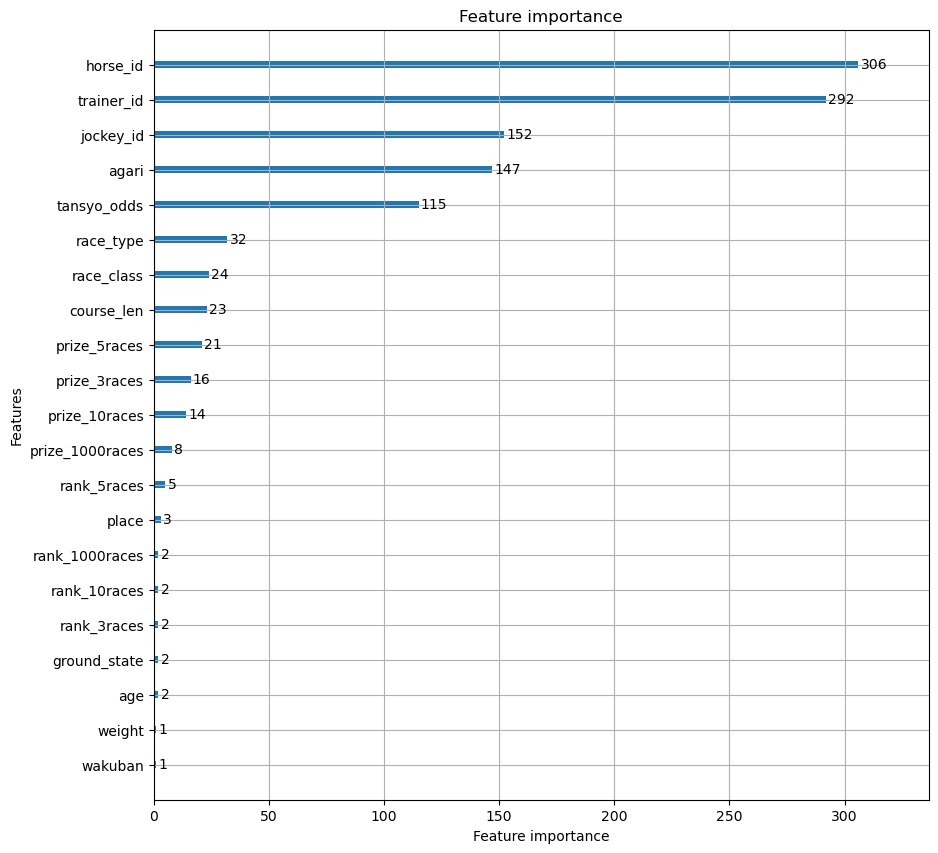

In [60]:
import lightgbm as lgb
lgb.plot_importance(r.model,figsize=(10,10))

In [314]:
import pandas as pd
evaluation_df.groupby(pd.cut(evaluation_df["pred"], [0,0.2,0.4,0.6,0.8,1.0])).agg(
    win_rate=("target", "mean"),
    count=("target", "count")
)


/tmp/ipykernel_825182/2046811631.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  evaluation_df.groupby(pd.cut(evaluation_df["pred"], [0,0.2,0.4,0.6,0.8,1.0])).agg(


,win_rate,count
pred,,
"(0.0, 0.2]",0.040363,27401
"(0.2, 0.4]",0.254489,2896
"(0.4, 0.6]",0.433440,939
"(0.6, 0.8]",0.519481,154
"(0.8, 1.0]",0.000000,1


In [315]:
evaluation_df["pred_bin"] = pd.qcut(evaluation_df["pred"], 10, duplicates="drop")

calib = evaluation_df.groupby("pred_bin").agg(
    mean_pred=("pred", "mean"),
    win_rate=("target", "mean"),
    count=("target", "count"),
)

calib


/tmp/ipykernel_825182/742031210.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  calib = evaluation_df.groupby("pred_bin").agg(


,mean_pred,win_rate,count
pred_bin,,,
"(0.00224, 0.00377]",0.003514,0.000636,3143
"(0.00377, 0.0063]",0.004611,0.002232,3136
"(0.0063, 0.0102]",0.008025,0.006690,3139
"(0.0102, 0.0177]",0.013761,0.010831,3139
"(0.0177, 0.0286]",0.022697,0.028034,3139
"(0.0286, 0.0466]",0.036923,0.039822,3139
"(0.0466, 0.0755]",0.059667,0.059573,3139
"(0.0755, 0.129]",0.099064,0.093023,3139
"(0.129, 0.245]",0.177246,0.170436,3139


In [316]:
evaluation_df["rank_pred"] = (
    evaluation_df
    .groupby("race_id")["pred"]
    .rank(ascending=False)
)

evaluation_df.groupby("rank_pred")["target"].mean().head(5)


rank_pred
1.0    0.374302
2.0    0.208423
3.0    0.122905
4.0    0.085088
5.0    0.066180
Name: target, dtype: float64